In [ ]:
import pandas as pd
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="harshit25",
    database="customer_behaviour"
)

query = """
SELECT 
    age_group,
    SUM(purchase_amount) AS total_revenue
FROM customer_shopping
GROUP BY age_group
ORDER BY total_revenue DESC;
"""

df = pd.read_sql(query, conn)

df

In [ ]:
import matplotlib.pyplot as plt

plt.bar(df['age_group'], df['total_revenue'])

plt.xlabel("Age Group")
plt.ylabel("Revenue")
plt.title("Revenue by Age Group")

plt.show()

In [ ]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="harshit25",
    database="customer_behaviour"
)

query = """
SELECT 
    gender,
    SUM(purchase_amount) AS total_revenue
FROM customer_shopping
GROUP BY gender;
"""

df = pd.read_sql(query, conn)

df

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(
    df['gender'],
    df['total_revenue'] ,
    color = "lightgreen"
)

plt.xlabel("Gender")
plt.ylabel("Total Revenue")
plt.title("Revenue Generated by Gender")

plt.show()

In [ ]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="harshit25",
    database="customer_behaviour"
)

query = """
 SELECT 
	age_group ,
    sum(purchase_amount) AS Total_revenue_by_age_group
FROM customer_shopping 
GROUP BY age_group 
ORDER BY Total_revenue_by_age_group DESC;
"""

df = pd.read_sql(query, conn)

df

In [ ]:
plt.figure(figsize=(6, 4))

plt.bar(
    df['age_group'] ,
    df['Total_revenue_by_age_group'] , 
    color = "skyblue"
)

plt.xlabel('Age_group')
plt.ylabel('purchase_amount')
plt.legend()
plt.title(' Total_revenue_by_age_group')
plt.show()

In [ ]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="harshit25",
    database="customer_behaviour"
)

query = """
SELECT 
	item_purchased , ROUND(AVG(review_rating) , 2) as AVG_Review_Rating
FROM customer_shopping
GROUP BY item_purchased
ORDER BY AVG_Review_Rating desc
limit 5 ;
"""

df = pd.read_sql(query, conn)

df

In [ ]:
plt.figure(figsize = (5,4))

plt.barh(
    df['item_purchased'] ,
    df['AVG_Review_Rating'] , 
    color = 'lightpink' ,
    label = 'top 5 products'
)

plt.xlabel('Purchased item')
plt.ylabel('AVG Review Rating')
# plt.legend()
plt.title('top 5 products with the highest average review rating')
plt.show()


In [ ]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="harshit25",
    database="customer_behaviour"
)

query = """
SELECT 
    subscription_status ,
    AVG(purchase_amount) AS avg_purchase ,
    SUM(purchase_amount) AS total_amount
FROM customer_shopping
WHERE subscription_status in ('Yes' , 'No')
GROUP BY subscription_status;
"""

df = pd.read_sql(query, conn)

df

In [ ]:
plt.figure(figsize = (8 ,4))

plt.bar(
    df['avg_purchase'],
    df['total_amount'] , 
    color = 'forestgreen'
)

plt.xlabel('total_amount')
plt.ylabel("avg_purchase")
plt.title('subscriber customer vs  non-subscribed customers')
plt.show()

In [ ]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="harshit25",
    database="customer_behaviour"
)

query = """
SELECT 
    COUNT(*) as customer_count,
    CASE
				WHEN previous_purchases = 1 THEN "NEW" 
                WHEN previous_purchases BETWEEN 2 AND 10 THEN "Returning"
                WHEN previous_purchases > 10 THEN "Loyal"
	END as Customers_loyalty
FROM customer_shopping
GROUP BY Customers_loyalty ;
"""

df = pd.read_sql(query, conn)

df

In [ ]:
# plt.figure(figsize= (6 ,4))

values = [3116 , 701 , 83]
labels = ["Loyal" , "Returning" , "New"]

plt.pie(
    values ,
    labels = labels, 
    autopct = "%1.1f%%" ,
    startangle=90
)

plt.title("Customers loyalty")
plt.show()


In [1]:
import mysql.connector
import pandas as pd

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="harshit25",
    database="customer_behaviour"
)

query = """
SELECT 
    shipping_type,
    AVG(purchase_amount) AS avg_purchase
FROM customer_shopping
WHERE shipping_type in ('Standard' , 'Express')
GROUP BY shipping_type;

"""

df = pd.read_sql(query, conn)

df

C:\Users\hp\AppData\Local\Temp\ipykernel_4000\2504188503.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,shipping_type,avg_purchase
0,Express,60.4752
1,Standard,58.4602


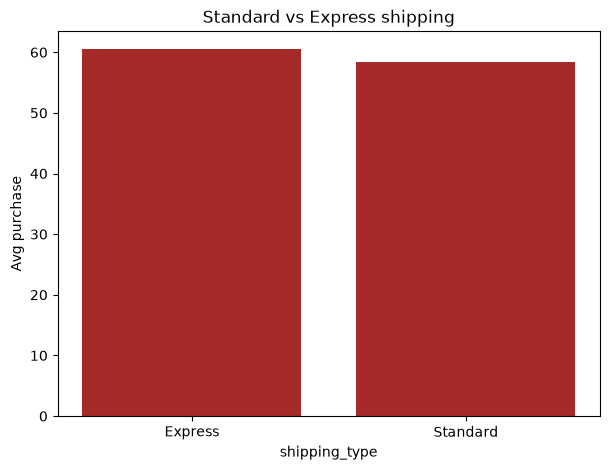

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize = (7 ,5))

plt.bar(
    df['shipping_type'] , 
    df['avg_purchase'] ,
    color = 'brown'
)

plt.xlabel('shipping_type')
plt.ylabel('Avg purchase')
plt.title('Standard vs Express shipping')
plt.show()

In [ ]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="harshit25",
    database="customer_behaviour"
)

query = """
SELECT 
    item_purchased,
    COUNT(CASE WHEN discount_applied = 'Yes' THEN 1 END) AS discounted_purchases,
    ROUND(
        (100 * COUNT(CASE WHEN discount_applied = 'Yes' THEN 1 END) / COUNT(*)),
        2
    ) AS percentage_of_discounts
FROM customer_shopping
GROUP BY item_purchased
ORDER BY percentage_of_discounts DESC;
"""

df = pd.read_sql(query, conn)

df

In [ ]:
plt.figure(figsize = (8 , 8))

values = df['percentage_of_discounts'].tolist()
labels = df['item_purchased'].tolist()

plt.pie(
    values,
    labels = labels,
    autopct = '%1.1f%%',
    startangle = 140
)

plt.title('products receive the highest discount usage')
plt.show()

In [ ]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="harshit25",
    database="customer_behaviour"
)

query = """
SELECT 
    category,
    ROUND(AVG(review_rating), 2) AS avg_review_rating
FROM customer_shopping
GROUP BY category
ORDER BY avg_review_rating DESC;
"""

df = pd.read_sql(query, conn)

df

In [ ]:
plt.figure(figsize = (6 , 4))

plt.bar(
    df['category'],
    df['avg_review_rating'],
    color = "yellow"
)

plt.xlabel('Category')
plt.ylabel('Avg review rating')
plt.title('category has the highest average review rating')
plt.show()